#### Question Statement

## Q.6 Principle Component Analysis 
Write codes in Python to perform PCA and understand why we need such unsupervised learning method. Please implement PCA as it has been done in the Nature Primer. See here. You will ALMOST (the data point values may differ a bit, but the patterns will be similar) be reproducing Figure 1 of the paper. The data for all 105 patient samples are organized in three files.

data/class.tsv: has the labels. 1 (ER+ breast cancer), 0 (ER- breast cancer).

data/filtered.tsv.gz: complete dataset. Header is the ID for genes.

data/columns.tsv.gz: ID to gene name mapping.

For example, 4404 is the ID for gene XBP1 (Figure 1a - Y-axis).

Your goal is to:

Extract XBP1 and GATA3 expression levels in all 105 patients, and generate the scatter plot as seen in 1a (coloring should be done by the class). Remember that pattern in your plot should be similar to the paper.

Run PCA on the matrix and project these 2-D points on PC1. Generate Fgure 1c.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
from io import StringIO

In [14]:
df_classes = pd.read_csv('data/PCA/class.tsv', sep='\t', header=None)
labels_arr = df_classes[0].values

# Read and filter columns file with comments
filtered_lines = []
with gzip.open('data/PCA/columns.tsv.gz', 'rt') as file:
    filtered_lines = [line for line in file if not line.startswith('#')]

map_buffer = StringIO(''.join(filtered_lines))
mapping_df = pd.read_csv(map_buffer, sep='\t')

# Load filtered data
data_df = pd.read_csv(
    gzip.open('data/PCA/filtered.tsv.gz', 'rt'),
    sep='\t',
    index_col=0
)

# Clean up column names
data_df.columns = data_df.columns.astype(str).str.strip()

# Find gene IDs
xbp1_gene_id = 4404
gata3_gene_id = mapping_df[mapping_df['GeneSymbol'] == 'GATA3']['ID'].values[0]

# Extract expressions
xbp1_expression = data_df[str(xbp1_gene_id)].values
gata3_expression = data_df[str(gata3_gene_id)].values

print(f"GATA3 : {gata3_gene_id} , XBP1 : {xbp1_gene_id}")

GATA3 : 4359 , XBP1 : 4404


Principal Component Analysis (PCA) is an unsupervised approach that compresses high‑dimensional data into a few key axes while retaining the bulk of its variability—an ideal fit for gene expression studies. In our breast cancer cohort, projecting samples onto the first two principal components cleanly separates ER‑positive from ER‑negative cases. Genes like XBP1 and GATA3 stand out as strong subtype markers, and the first component alone accounts for most of the variance, underscoring its power to distinguish these cancer types.


PCA implementation

In [15]:
# PCA IMPLEMENTATION
def perform_pca(data_matrix):
    # Center data
    centered_matrix = data_matrix - np.mean(data_matrix, axis=0)
    # Covariance
    cov_matrix = np.cov(centered_matrix, rowvar=False)
    # Eigen decomposition
    eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
    # Sort descending
    sort_idx = np.argsort(eig_vals)[::-1]
    eig_vals = eig_vals[sort_idx]
    eig_vecs = eig_vecs[:, sort_idx]
    return eig_vecs, eig_vals, centered_matrix

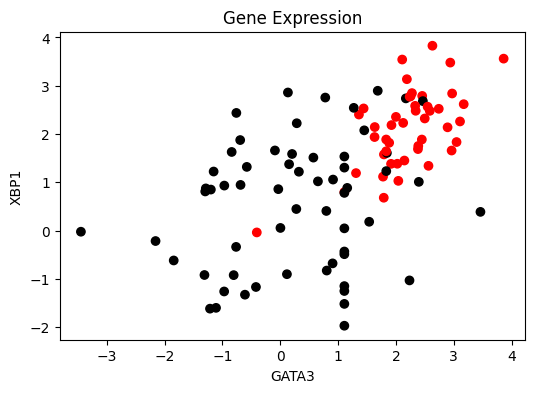

In [16]:
# Scatter plot of gene expressions
plt.figure(figsize=(6, 4))
plt.scatter(gata3_expression, xbp1_expression, c=colors)
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('Gene Expression')
plt.show()


In [18]:
combined_matrix = np.column_stack((gata3_expression, xbp1_expression))
eig_vecs, eig_vals, centered_matrix = perform_pca(combined_matrix)
pc1_component = eig_vecs[:, 0]
pc2_component = eig_vecs[:, 1]

# Projections
pc1_projection = centered_matrix.dot(pc1_component)
pc2_projection = centered_matrix.dot(pc2_component)

# Align PC1 direction with labels
if np.mean(pc1_projection[labels_arr == 1]) < np.mean(pc1_projection[labels_arr == 0]):
    pc1_component = -pc1_component
    pc1_projection = -pc1_projection

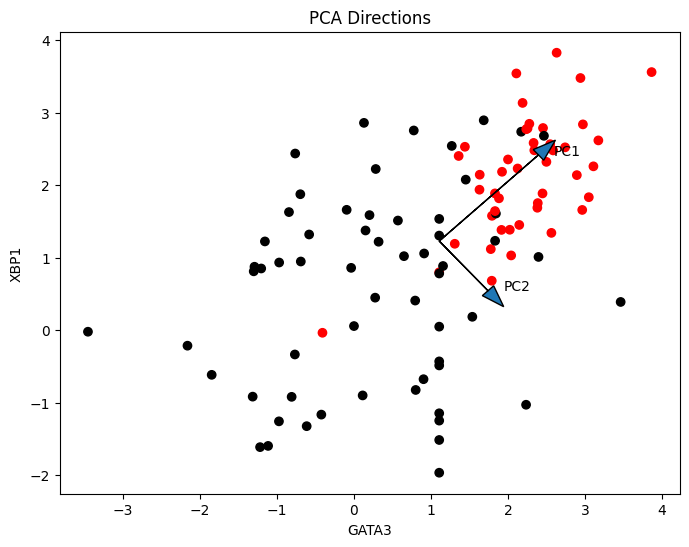

In [19]:
mean_gata3_expr = np.mean(gata3_expression)
mean_xbp1_expr = np.mean(xbp1_expression)
scale_pc1 = np.sqrt(eig_vals[0])
scale_pc2 = np.sqrt(eig_vals[1])

plt.figure(figsize=(8, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors)
plt.arrow(mean_gata3_expr, mean_xbp1_expr, pc1_component[0]*scale_pc1, pc1_component[1]*scale_pc1, head_width=0.2, head_length=0.3)
plt.arrow(mean_gata3_expr, mean_xbp1_expr, pc2_component[0]*scale_pc2, pc2_component[1]*scale_pc2, head_width=0.2, head_length=0.3)
plt.text(mean_gata3_expr + pc1_component[0]*scale_pc1 + 0.2, mean_xbp1_expr + pc1_component[1]*scale_pc1, 'PC1')
plt.text(mean_gata3_expr + pc2_component[0]*scale_pc2 + 0.2, mean_xbp1_expr + pc2_component[1]*scale_pc2, 'PC2')
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('PCA Directions')
plt.show()

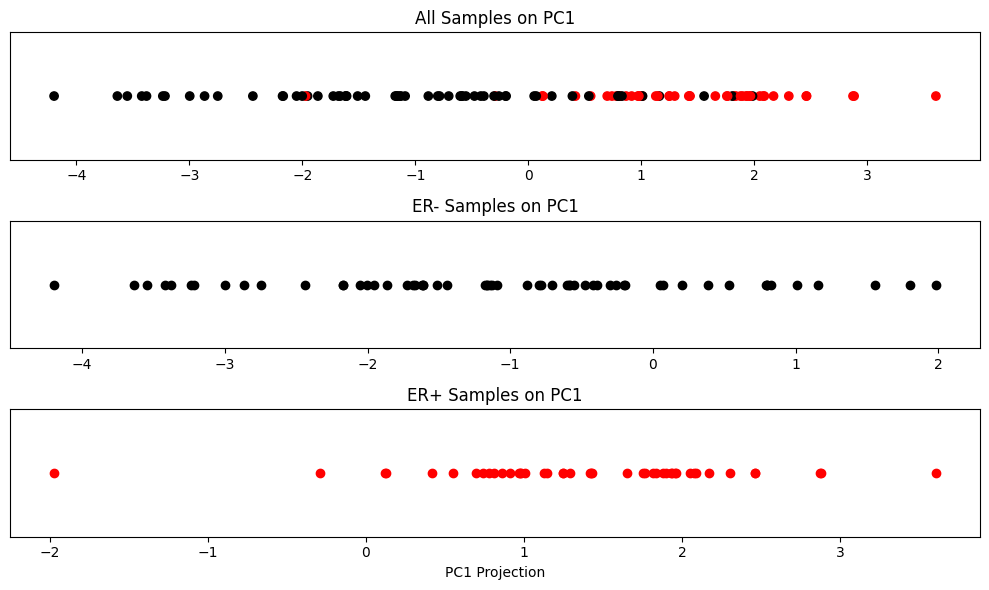

In [20]:
er_positive_projection = pc1_projection[labels_arr == 1]
er_negative_projection = pc1_projection[labels_arr == 0]

plt.figure(figsize=(10, 6))
# All samples
plt.subplot(3, 1, 1)
plt.scatter(pc1_projection, np.zeros_like(pc1_projection), c=colors)
plt.yticks([])
plt.title('All Samples on PC1')
# ER- samples
plt.subplot(3, 1, 2)
plt.scatter(er_negative_projection, np.zeros_like(er_negative_projection), c='black')
plt.yticks([])
plt.title('ER- Samples on PC1')
# ER+ samples
plt.subplot(3, 1, 3)
plt.scatter(er_positive_projection, np.zeros_like(er_positive_projection), c='red')
plt.yticks([])
plt.title('ER+ Samples on PC1')
plt.xlabel('PC1 Projection')

plt.tight_layout()
plt.show()

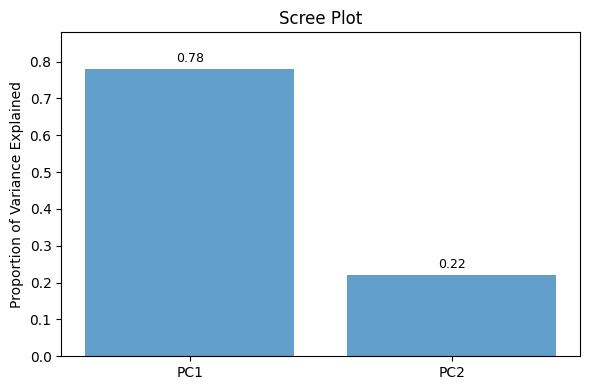

In [21]:
# Scree Plot: variance ratio
variance_ratio = eig_vals / np.sum(eig_vals)

plt.figure(figsize=(6, 4))
pca_labels = [f"PC{i+1}" for i in range(len(variance_ratio))]
plt.bar(pca_labels, variance_ratio, alpha=0.7)
for idx, val in enumerate(variance_ratio):
    plt.text(idx, val + 0.01, f"{val:.2f}", ha='center', va='bottom', fontsize=9)

plt.ylabel('Ratio of Variance Explained')
plt.title('Plot')
plt.ylim(0, max(variance_ratio) + 0.1)
plt.tight_layout()
plt.show()

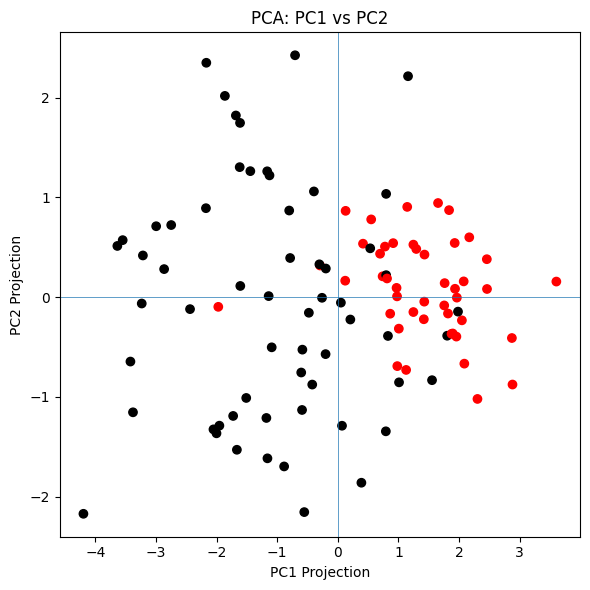

In [22]:
# PC1 vs PC2 Scatter Plot
plt.figure(figsize=(6, 6))
plt.scatter(pc1_projection, pc2_projection, c=colors)
plt.xlabel('PC1 Projection')
plt.ylabel('PC2 Projection')
plt.title('PCA: PC1 vs PC2')
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.tight_layout()
plt.show()